In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('country_wise_latest.csv')
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [6]:
df.isnull().sum()b

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [7]:
df.shape


(187, 15)

In [8]:
df.duplicated().sum()

0

In [9]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


<Axes: xlabel='WHO Region', ylabel='count'>

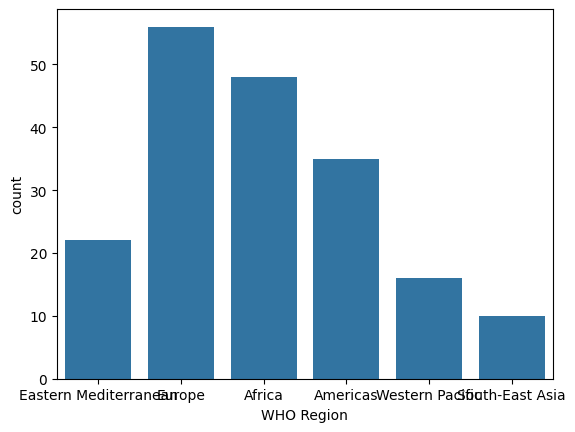

In [13]:
sns.countplot( x  = df['WHO Region'])

In [14]:
df['WHO Region'].value_counts()

WHO Region
Europe                   56
Africa                   48
Americas                 35
Eastern Mediterranean    22
Western Pacific          16
South-East Asia          10
Name: count, dtype: int64

In [17]:
df.columns


Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

<Axes: xlabel='New deaths'>

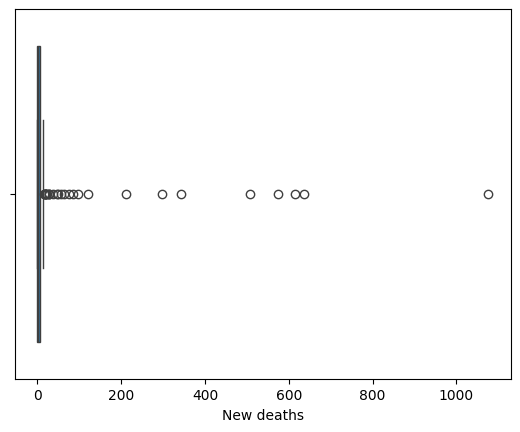

In [21]:
sns.boxplot(x = df['New deaths'])

In [23]:
df['New deaths'].min()

0

## Country Based Analysis

### 1. Which countries had the highest confirmed cases?

In [35]:
top_cases = df.groupby('Country/Region')['Confirmed'].max().sort_values(ascending = False)
print(type(top_cases))
top = top_cases.head(5)
top

<class 'pandas.core.series.Series'>


Country/Region
US              4290259
Brazil          2442375
India           1480073
Russia           816680
South Africa     452529
Name: Confirmed, dtype: int64

### Ans: as we can see that the US had the highest number of confirmed cases of covid-19.

<Axes: xlabel='Country/Region', ylabel='Confirmed'>

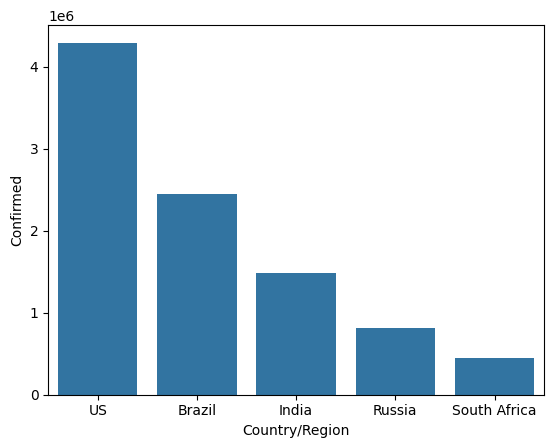

In [36]:
sns.barplot(top)

### 2. Which countries had the highest deaths?

<Axes: xlabel='Country/Region'>

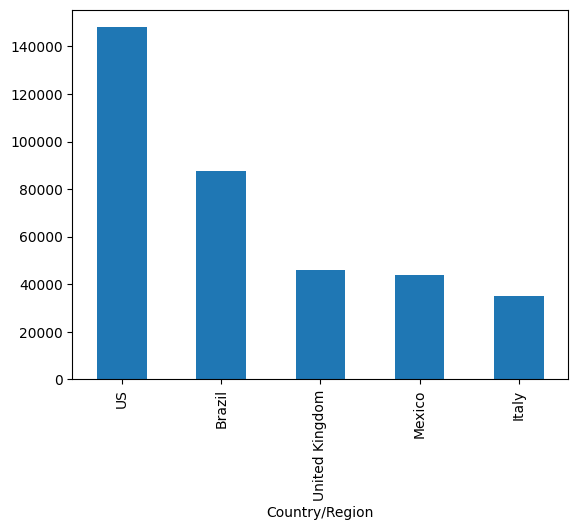

In [39]:
df.groupby('Country/Region')['Deaths'].max().sort_values(ascending = False).head(5).plot(kind = 'bar')

### Analysis between the confirmed cases and deaths for the countries

<Axes: xlabel='Country/Region', ylabel='Confirmed'>

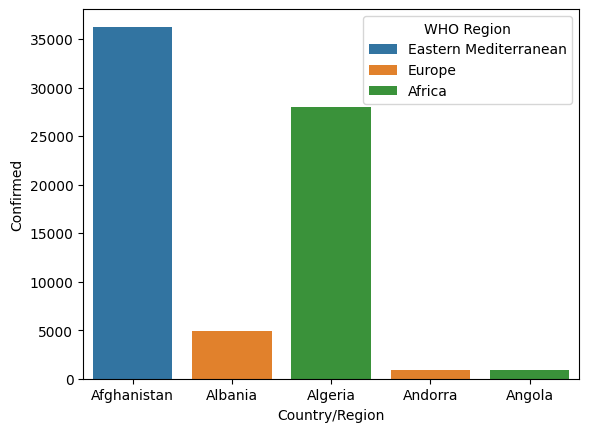

In [43]:
my_df = df.head(5)
sns.barplot(x = my_df['Country/Region'], y = my_df['Confirmed'], hue = my_df['WHO Region'])

### 3. Which countries had the highest recoveries?

<Axes: xlabel='Country/Region'>

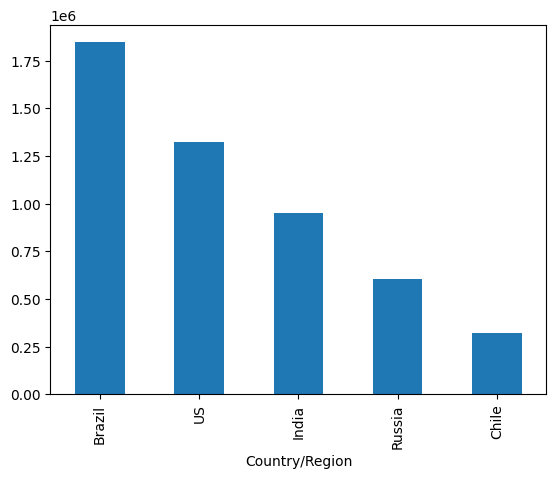

In [48]:
df.groupby('Country/Region')['Recovered'].max().sort_values(ascending = False).head(5).plot(kind = 'bar')

In [49]:
df.sample(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
40,Congo (Kinshasa),8844,208,5700,2936,13,4,190,2.35,64.45,3.65,8443,401,4.75,Africa
150,Singapore,50838,27,45692,5119,469,0,171,0.05,89.88,0.06,48035,2803,5.84,Western Pacific
101,Lithuania,2019,80,1620,319,11,0,4,3.96,80.24,4.94,1947,72,3.70,Europe
152,Slovenia,2087,116,1733,238,5,0,55,5.56,83.04,6.69,1953,134,6.86,Europe
116,Morocco,20887,316,16553,4018,609,3,115,1.51,79.25,1.91,17562,3325,18.93,Eastern Mediterranean
74,Haiti,7340,158,4365,2817,25,1,0,2.15,59.47,3.62,7053,287,4.07,Americas
52,Egypt,92482,4652,34838,52992,420,46,1007,5.03,37.67,13.35,88402,4080,4.62,Eastern Mediterranean
21,Bosnia and Herzegovina,10498,294,4930,5274,731,14,375,2.80,46.96,5.96,8479,2019,23.81,Europe
44,Cuba,2532,87,2351,94,37,0,2,3.44,92.85,3.70,2446,86,3.52,Americas
71,Guinea,7055,45,6257,753,47,2,105,0.64,88.69,0.72,6590,465,7.06,Africa


## Mortality Analysis for each country.

### 1. what is the death rate of each country?

In [88]:
country_stat = df.groupby('Country/Region')[['Confirmed', 'Deaths']].max()
country_stat['Death_rate'] = (country_stat['Deaths'] / country_stat['Confirmed']) * 100
df2 = country_stat.head(5).reset_index()
df2 

,Country/Region,Confirmed,Deaths,Death_rate
0,Afghanistan,36263,1269,3.499435
1,Albania,4880,144,2.950820
2,Algeria,27973,1163,4.157581
3,Andorra,907,52,5.733186
4,Angola,950,41,4.315789


<Axes: xlabel='Confirmed', ylabel='Death_rate'>

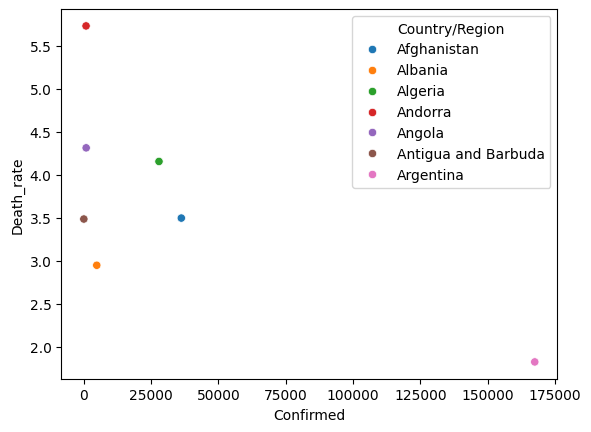

In [71]:
sns.scatterplot(x = df2['Confirmed'], y = df2['Death_rate'], hue = df2['Country/Region'])

### Conclusion: In some country although the the confirmed cases are less but the death rate is very high (eg. Andorra) .

<Axes: xlabel='Confirmed', ylabel='Deaths'>

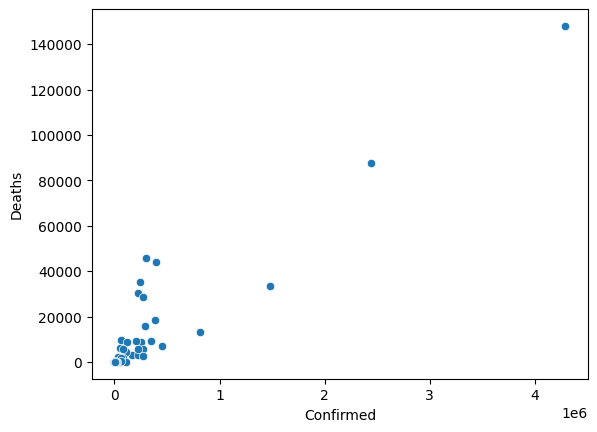

In [81]:
sns.scatterplot(x = df['Confirmed'], y = df['Deaths'])

### 2 . Which countries are outliers in deaths?

<Axes: xlabel='Deaths'>

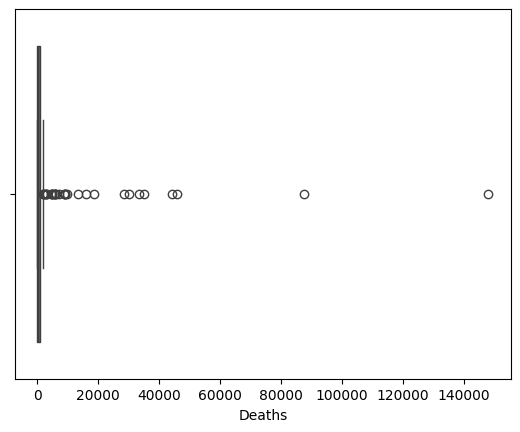

In [97]:

sns.boxplot(x = df['Deaths'])

### 3. Which countries had low deaths despite high confirmed cases?

In [100]:
country_stat.sort_values(by = ['Confirmed', 'Deaths'], ascending = [False, True])

,Confirmed,Deaths,Death_rate
Country/Region,,,
US,4290259,148011,3.449932
Brazil,2442375,87618,3.587410
India,1480073,33408,2.257186
Russia,816680,13334,1.632708
South Africa,452529,7067,1.561668
...,...,...,...
Dominica,18,0,0.000000
Saint Kitts and Nevis,17,0,0.000000
Greenland,14,0,0.000000
